Forecasting Model

To predict future electricity demand.

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Load data
df = pd.read_csv("/Users/jussaragaspar/Downloads/Final project/time_series_60min_singleindex_filtered.csv")

# Convert timestamp
df["utc_timestamp"] = pd.to_datetime(df["utc_timestamp"])
df = df.set_index("utc_timestamp")

# Keep only FRANCE demand first
df_model = df[["FR_load_actual_entsoe_transparency"]].dropna().copy()

In [52]:
# Lag features
df_model["lag_6"] = df_model["FR_load_actual_entsoe_transparency"].shift(6)
df_model["lag_48"] = df_model["FR_load_actual_entsoe_transparency"].shift(24)
df_model["lag_72"] = df_model["FR_load_actual_entsoe_transparency"].shift(72)
df_model["lag_168"] = df_model["FR_load_actual_entsoe_transparency"].shift(168)
# Time features
df_model["hour"] = df_model.index.hour
df_model["dayofweek"] = df_model.index.dayofweek

df_model = df_model.dropna()

In [53]:
X = df_model[["lag_6", "lag_48", "lag_72", "lag_168" ,"hour", "dayofweek"]]
y = df_model["FR_load_actual_entsoe_transparency"]

In [54]:
split = int(len(df_model) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [55]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [56]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
print("MAE:", mae)

MAE: 1321.0341789533143


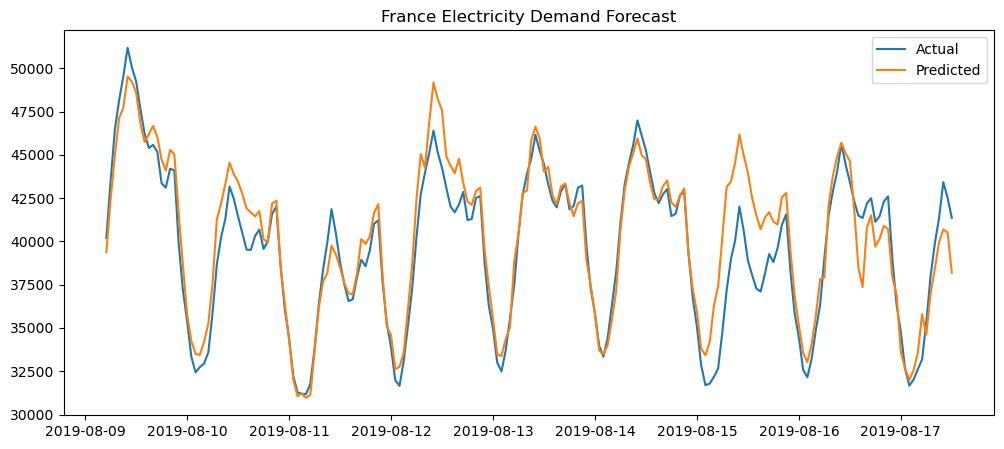

In [57]:
plt.figure(figsize=(12,5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], pred[:200], label="Predicted")
plt.legend()
plt.title("France Electricity Demand Forecast")
plt.show()

<Axes: >

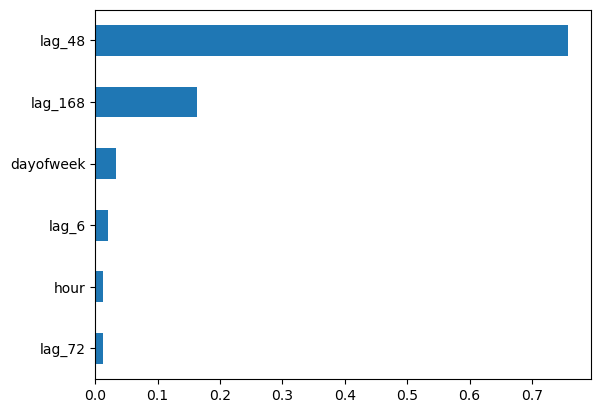

In [58]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind="barh")

The model mainly uses weekly repetition (lag 168) to predict demand.

**HOUR PATTERN**

<Axes: xlabel='utc_timestamp'>

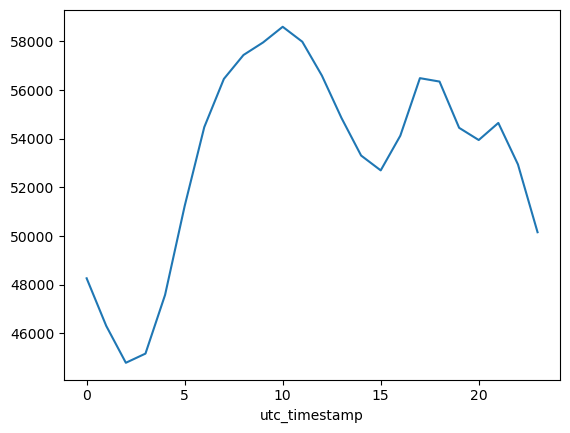

In [59]:
df_model.groupby(df_model.index.hour)["FR_load_actual_entsoe_transparency"].mean().plot()

**DAILY PATTERN**

<Axes: xlabel='utc_timestamp'>

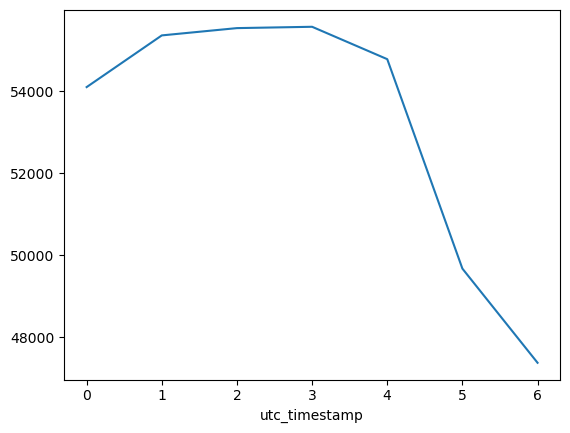

In [60]:
df_model.groupby(df_model.index.dayofweek)["FR_load_actual_entsoe_transparency"].mean().plot()

**WEEKLY PATTERN**

<Axes: xlabel='utc_timestamp'>

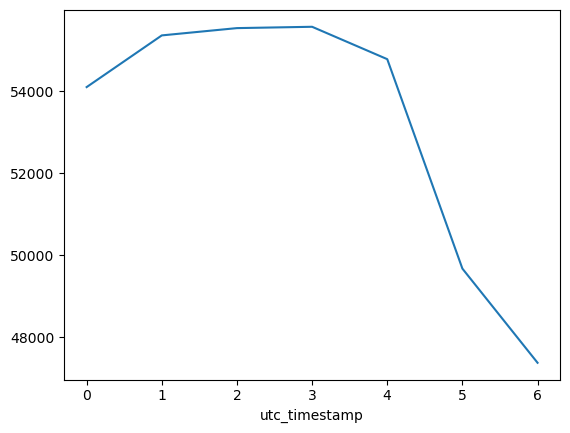

In [61]:
df_model.groupby(df_model.index.dayofweek)["FR_load_actual_entsoe_transparency"].mean().plot()

📍`conclusions`


Electricity demand shows strong temporal patterns driven by human activity. In particular, both daily and weekly cycles are clearly visible in the data. Lag 24 represents the demand at the same hour on the previous day, capturing the daily repetition of electricity usage (e.g., morning and evening peaks). Similarly, lag 168 represents the demand at the same hour in the previous week, capturing weekly patterns such as differences between weekdays and weekends.